In [98]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt


In [99]:
# Import data
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\data\processed\CDC.csv', parse_dates=['obs_date'])

# Rename 'obs_date' to 'date' and set it as the index
data.rename(columns={'obs_date': 'date'}, inplace=True)
data.set_index('date', inplace=True)

# Display the first 10 rows
data.head(10)

,indicator,API_UserName,OpDiv,observations,curr_date
date,,,,,
2025-01-01,146.71.50.198,818860012482918321,CDC,1,2025-01-01
2025-01-01,149.36.49.225,818860012482918321,CDC,28,2025-01-01
2025-01-01,162.142.125.242,818860012482918321,CDC,3,2025-01-01
2025-01-01,162.142.125.247,818860012482918321,CDC,2,2025-01-01
2025-01-01,185.230.63.171,818860012482918321,CDC,6,2025-01-01
2025-01-01,23.26.221.12,818860012482918321,CDC,49,2025-01-01
2025-01-01,23.26.221.2,818860012482918321,CDC,51,2025-01-01
2025-01-01,23.26.221.4,818860012482918321,CDC,36,2025-01-01
2025-01-01,34.160.111.145,818860012482918321,CDC,4,2025-01-01


In [100]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1321 entries, 2025-01-01 to 2025-04-14
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   indicator     1321 non-null   object
 1   API_UserName  1321 non-null   int64 
 2   OpDiv         1321 non-null   object
 3   observations  1321 non-null   int64 
 4   curr_date     1321 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.9+ KB


In [101]:
unique_indicators_count = data['indicator'].nunique()
print(f"Number of unique indicators: {unique_indicators_count}")

Number of unique indicators: 162


In [102]:
unique_indicator_frequency_count = data['indicator'].value_counts()
print("Unique Indicator Frequency Count:")
print(unique_indicator_frequency_count.to_string())

Unique Indicator Frequency Count:
indicator
104.21.48.1                        91
34.160.111.145                     85
172.240.108.68                     79
185.230.63.171                     74
104.21.54.132                      58
162.142.125.242                    53
104.21.61.32                       52
162.142.125.247                    46
146.71.50.198                      34
162.142.125.255                    31
68.67.179.164                      31
104.18.32.191                      20
185.253.162.21                     19
www.shorturl.at/                   18
156.146.63.131                     17
15.235.218.150                     14
156.146.63.174                     12
178.175.129.35                     12
23.205.105.180                     12
84.239.31.15                       12
72.21.210.29                       12
156.146.63.171                     12
156.146.63.169                     11
64.64.112.159                      11
156.146.63.163                      9
156.14

In [103]:
ip_data = data[data['indicator'] == '104.18.32.191']
display(ip_data)

,indicator,API_UserName,OpDiv,observations,curr_date
date,,,,,
2025-01-03,104.18.32.191,818860012482918321,CDC,10,2025-01-03
2025-01-06,104.18.32.191,818860012482918321,CDC,3,2025-01-06
2025-01-08,104.18.32.191,818860012482918321,CDC,3,2025-01-08
2025-01-30,104.18.32.191,818860012482918321,CDC,10,2025-01-30
2025-02-03,104.18.32.191,818860012482918321,CDC,5,2025-02-03
2025-02-12,104.18.32.191,818860012482918321,CDC,6,2025-02-12
2025-02-18,104.18.32.191,818860012482918321,CDC,3,2025-02-18
2025-02-19,104.18.32.191,818860012482918321,CDC,3,2025-02-19
2025-02-25,104.18.32.191,818860012482918321,CDC,15,2025-02-25


In [104]:
# Convert observations to binary appearance flags
pivot_df = data.pivot_table(index='date', columns='indicator', values='observations', aggfunc='count')

# Ensure daily frequency and fill missing values
pivot_df = pivot_df.asfreq('D').fillna(0)
top_indicators = pivot_df.sum().nlargest(10).index  # Select top 10 indicators
pivot_df = pivot_df[top_indicators]
pivot_df.head(10)


indicator,104.21.48.1,34.160.111.145,172.240.108.68,185.230.63.171,104.21.54.132,162.142.125.242,104.21.61.32,162.142.125.247,146.71.50.198,162.142.125.255
date,,,,,,,,,,
2025-01-01,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
2025-01-02,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
2025-01-03,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
2025-01-04,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2025-01-05,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
2025-01-06,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
2025-01-07,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
2025-01-08,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2025-01-09,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [105]:
# Difference the data
pivot_df = pivot_df.diff().dropna()

In [106]:
# make sure data is stationary
def check_stationarity(data):
    from statsmodels.tsa.stattools import adfuller
    stationary_columns = []
    for column in data.columns:
        result = adfuller(data[column].dropna())  # Drop NaN values before applying the test
        print(f"Column: {column}")
        print('ADF Statistic:', result[0])
        print('p-value:', result[1])
        if result[1] <= 0.05:
            print("Data is stationary")
            stationary_columns.append(column)
        else:
            print("Data is non-stationary")
        print("-" * 50)
    return stationary_columns


# Check stationarity for each column in pivot_df
stationary_columns = check_stationarity(pivot_df)
print(f"Stationary columns: {stationary_columns}")


Column: 104.21.48.1
ADF Statistic: -8.603078583661208
p-value: 6.785940726987563e-14
Data is stationary
--------------------------------------------------
Column: 34.160.111.145
ADF Statistic: -7.525821426759897
p-value: 3.687283273326655e-11
Data is stationary
--------------------------------------------------
Column: 172.240.108.68
ADF Statistic: -4.139542700457238
p-value: 0.0008325983684561515
Data is stationary
--------------------------------------------------
Column: 185.230.63.171
ADF Statistic: -3.9314824004403843
p-value: 0.0018149906474628978
Data is stationary
--------------------------------------------------
Column: 104.21.54.132
ADF Statistic: -7.388336789962288
p-value: 8.124542010553752e-11
Data is stationary
--------------------------------------------------
Column: 162.142.125.242
ADF Statistic: -6.4519977929341445
p-value: 1.515411953753139e-08
Data is stationary
--------------------------------------------------
Column: 104.21.61.32
ADF Statistic: -9.16318429555804

Column: 146.71.50.198
ADF Statistic: -8.880376416447419
p-value: 1.3229191995131443e-14
Data is stationary
--------------------------------------------------
Column: 162.142.125.255
ADF Statistic: -6.21764299287607
p-value: 5.317582967105525e-08
Data is stationary
--------------------------------------------------
Stationary columns: ['104.21.48.1', '34.160.111.145', '172.240.108.68', '185.230.63.171', '104.21.54.132', '162.142.125.242', '104.21.61.32', '162.142.125.247', '146.71.50.198', '162.142.125.255']


In [114]:
# Split the data (80/20) ===
split_index = int(len(pivot_df) * 0.8)
train_df = pivot_df.iloc[:split_index]
test_df = pivot_df.iloc[split_index:]

# Build and fit the VAR model ===
model = VAR(train_df)
results = model.fit(maxlags=1, ic='aic')

# Define forecast horizon ===
forecast_steps = 7

# Forecast future values ===
forecast_input = train_df.values[-results.k_ar:]
forecast_raw = results.forecast(y=forecast_input, steps=forecast_steps)
# Adjust the index of forecast_df to match the forecast horizon
forecast_index = test_df.index[:forecast_steps]
forecast_df = pd.DataFrame(forecast_raw, index=forecast_index, columns=pivot_df.columns)

# Normalize forecasted values (min-max scaling per indicator) ===
min_vals = train_df.min()
max_vals = train_df.max()
range_vals = (max_vals - min_vals).replace(0, 1)  # Avoid division by zero

forecast_probs = (forecast_df - min_vals) / range_vals
forecast_probs = forecast_probs.clip(0, 1)

# === Final: Threshold very small values to zero (noise filter) ===
forecast_probs[forecast_probs < 0.01] = 0

# Display results ===
print("\n Calibrated Probabilities from VAR Forecast:")
display(forecast_probs)



 Calibrated Probabilities from VAR Forecast:


indicator,104.21.48.1,34.160.111.145,172.240.108.68,185.230.63.171,104.21.54.132,162.142.125.242,104.21.61.32,162.142.125.247,146.71.50.198,162.142.125.255
date,,,,,,,,,,
2025-03-25,0.509711,0.473293,0.363684,0.312471,0.407740,0.272147,0.320887,0.575411,0.660598,0.265190
2025-03-26,0.496044,0.453797,0.586199,0.562750,0.539381,0.576318,0.547677,0.518705,0.415195,0.628944
2025-03-27,0.509906,0.533626,0.442119,0.451962,0.489129,0.493407,0.482939,0.458318,0.525726,0.440305
2025-03-28,0.504398,0.477040,0.531697,0.532783,0.511943,0.478718,0.500765,0.533581,0.503917,0.513448
2025-03-29,0.506312,0.512717,0.491842,0.473664,0.501314,0.518313,0.505467,0.477578,0.486044,0.509104
2025-03-30,0.506148,0.490374,0.499703,0.512852,0.507246,0.484756,0.493029,0.508831,0.512642,0.481472
2025-03-31,0.505610,0.504721,0.506343,0.489228,0.502890,0.504595,0.504381,0.497051,0.491204,0.516114


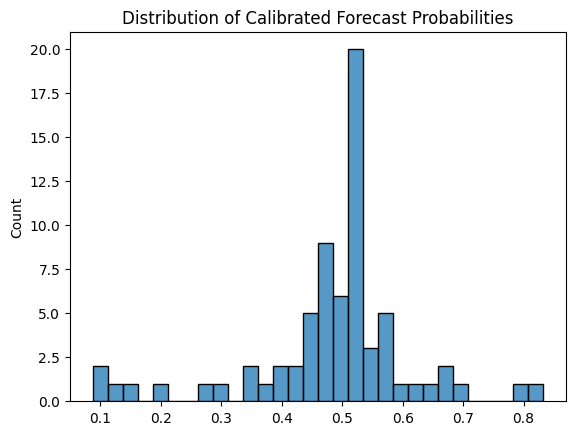

In [110]:
import seaborn as sns
sns.histplot(forecast_probs.values.flatten(), bins=30)
plt.title("Distribution of Calibrated Forecast Probabilities")
plt.show()
